# Few-Shot Fine-Tuning for Cross-Domain NER

Fine-tunes the CoNLL-2003 baseline encoder (Notebook 04) on two target domains — **WNUT-17** (social media) and **SciERC** (scientific abstracts) — under matched annotation budgets of 50, 100, and 200 labeled sentences, each repeated across three random seeds (13, 42, 101), for 18 runs total.

Because WNUT-17 and SciERC use entity types incompatible with the CoNLL-2003 label space, each run transfers only the baseline's encoder weights and attaches a newly initialized classification head sized to the target label inventory before fine-tuning.

Two test-set metrics are reported for every run:

- **Typed entity F1** — span and entity type must both be correct.
- **Boundary-only F1** — span match only, enabling direct comparison with the zero-shot cross-domain results from Notebook 04.


In [1]:
!pip -q install "transformers==4.44.2" "datasets==2.19.2" "seqeval==1.2.2" "accelerate>=0.26.0" pandas matplotlib

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. In Colab, select Runtime > Change runtime type > GPU.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 41.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
GPU available: True
GPU

## Environment Configuration

Suppresses known-benign library warnings (e.g. missing `HF_TOKEN`, expected re-initialization of the classification head) so output stays readable without masking genuine errors.


In [2]:
import os
import warnings
import logging

# Only suppress the specific noisy-but-harmless categories we actually expect --
# real errors (exceptions) are never affected by any of this.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*HF_TOKEN.*")
warnings.filterwarnings("ignore", message=".*newly initialized.*")

os.environ["TOKENIZERS_PARALLELISM"] = "false"      # silences the tokenizer fork warning
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"  # silences the Windows-symlink notice

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()  # transformers: only show actual errors, not routine notices
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)


## 1. Configuration

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_from_disk
from seqeval.metrics import precision_score, recall_score, f1_score
from transformers import (
    AutoConfig,
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

PROCESSED = Path("/content/drive/MyDrive/AAI590/data/processed")
TOKENIZED_DIR = PROCESSED / "tokenized"
LABELS_DIR = PROCESSED / "label_maps"
MODELS_DIR = PROCESSED / "models"
RESULTS_DIR = PROCESSED / "results"
BASELINE_DIR = MODELS_DIR / "baseline_conll2003"

FEWSHOT_RESULTS_DIR = RESULTS_DIR / "fewshot_v2"  # fresh dir -- avoids colliding with pre-budget-scaled runs
FEWSHOT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Experiment settings created in Notebooks 02 and 03
TARGET_DATASETS = ["wnut17", "scierc"]
BUDGETS = [50, 100, 200]
SEEDS = [13, 42, 101]

# Fine-tuning settings
LEARNING_RATE = 2e-5
# Budget-scaled epoch counts: smaller few-shot sets need more passes to converge.
NUM_EPOCHS_BY_BUDGET = {50: 20, 100: 12, 200: 8}
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 32
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 2

# Saving all 18 models can consume substantial Drive space.
# Set True only when you need every trained model later.
SAVE_ALL_MODELS = False

required_paths = [TOKENIZED_DIR, LABELS_DIR, BASELINE_DIR]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing required path: {path}\n"
            "Run Notebooks 03 and 04 successfully before running Notebook 05."
        )

print("Processed directory:", PROCESSED)
print("Baseline model:", BASELINE_DIR)
print("Results directory:", FEWSHOT_RESULTS_DIR)


Mounted at /content/drive
Processed directory: /content/drive/MyDrive/AAI590/data/processed
Baseline model: /content/drive/MyDrive/AAI590/data/processed/models/baseline_conll2003
Results directory: /content/drive/MyDrive/AAI590/data/processed/results/fewshot_v2


## 2. Baseline Model and Tokenizer

Only the baseline's BERT encoder is transferred to each target-domain model; the classification head is reinitialized per dataset to match its label inventory.


In [4]:
tokenizer = AutoTokenizer.from_pretrained(str(BASELINE_DIR), clean_up_tokenization_spaces=True)
baseline_model = AutoModelForTokenClassification.from_pretrained(str(BASELINE_DIR))

print("Baseline architecture:", baseline_model.config.model_type)
print("Baseline output labels:", baseline_model.config.num_labels)
print("Baseline encoder loaded successfully.")


Baseline architecture: bert
Baseline output labels: 8
Baseline encoder loaded successfully.


## 3. Metric and Data-Loading Utilities

In [5]:
def load_label_map(dataset_name):
    path = LABELS_DIR / f"{dataset_name}_label_map.json"
    with open(path) as f:
        mapping = json.load(f)

    label2id = {str(k): int(v) for k, v in mapping["label2id"].items()}
    id2label = {int(k): str(v) for k, v in mapping["id2label"].items()}
    return label2id, id2label


def collapse_to_boundary(tag):
    """Convert a typed BIO tag to O, B-ENT, or I-ENT."""
    if tag == "O":
        return "O"
    if tag.startswith("B-"):
        return "B-ENT"
    if tag.startswith("I-"):
        return "I-ENT"
    raise ValueError(f"Unexpected BIO tag: {tag}")


def decode_predictions(eval_pred, id2label):
    """Decode non-ignored labels and predictions into BIO tag sequences."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    true_tags = []
    predicted_tags = []

    for pred_row, label_row in zip(predictions, labels):
        sentence_true = []
        sentence_pred = []

        for pred_id, label_id in zip(pred_row, label_row):
            if label_id == -100:
                continue

            sentence_true.append(id2label[int(label_id)])
            sentence_pred.append(id2label[int(pred_id)])

        true_tags.append(sentence_true)
        predicted_tags.append(sentence_pred)

    return true_tags, predicted_tags


def build_compute_metrics(id2label):
    """Create a Trainer metric function for a target dataset's label map."""
    def compute_metrics(eval_pred):
        true_tags, predicted_tags = decode_predictions(eval_pred, id2label)

        true_boundary = [
            [collapse_to_boundary(tag) for tag in sentence]
            for sentence in true_tags
        ]
        predicted_boundary = [
            [collapse_to_boundary(tag) for tag in sentence]
            for sentence in predicted_tags
        ]

        return {
            "typed_precision": precision_score(true_tags, predicted_tags),
            "typed_recall": recall_score(true_tags, predicted_tags),
            "typed_f1": f1_score(true_tags, predicted_tags),
            "boundary_precision": precision_score(true_boundary, predicted_boundary),
            "boundary_recall": recall_score(true_boundary, predicted_boundary),
            "boundary_f1": f1_score(true_boundary, predicted_boundary),
        }

    return compute_metrics


def load_target_datasets(dataset_name, budget, seed):
    fewshot_path = (
        TOKENIZED_DIR / "fewshot" / dataset_name /
        f"budget{budget}_seed{seed}"
    )
    validation_path = TOKENIZED_DIR / dataset_name / "validation"
    test_path = TOKENIZED_DIR / dataset_name / "test"

    for path in [fewshot_path, validation_path, test_path]:
        if not path.exists():
            raise FileNotFoundError(
                f"Missing tokenized dataset: {path}\n"
                "Re-run Notebook 03 to create all tokenized few-shot splits."
            )

    return (
        load_from_disk(str(fewshot_path)),
        load_from_disk(str(validation_path)),
        load_from_disk(str(test_path)),
    )


def create_target_model(dataset_name):
    """Create a target-label model initialized with the CoNLL-trained encoder."""
    label2id, id2label = load_label_map(dataset_name)

    config = AutoConfig.from_pretrained(
        "bert-base-cased",
        num_labels=len(id2label),
        label2id=label2id,
        id2label=id2label,
    )

    target_model = AutoModelForTokenClassification.from_pretrained(
        "bert-base-cased",
        config=config,
        ignore_mismatched_sizes=True,
    )

    # Transfer the source-domain representation learned in Notebook 04.
    target_model.base_model.load_state_dict(
        baseline_model.base_model.state_dict(),
        strict=True,
    )

    return target_model, label2id, id2label


def cleanup_memory(*objects):
    for obj in objects:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 4. Input Validation

Confirms all required tokenized splits exist prior to training.


In [6]:
input_rows = []

for dataset_name in TARGET_DATASETS:
    label2id, id2label = load_label_map(dataset_name)

    for split in ["validation", "test"]:
        path = TOKENIZED_DIR / dataset_name / split
        input_rows.append({
            "dataset": dataset_name,
            "split": split,
            "budget": None,
            "seed": None,
            "exists": path.exists(),
            "path": str(path),
            "num_labels": len(id2label),
        })

    for budget in BUDGETS:
        for seed in SEEDS:
            path = (
                TOKENIZED_DIR / "fewshot" / dataset_name /
                f"budget{budget}_seed{seed}"
            )
            input_rows.append({
                "dataset": dataset_name,
                "split": "fewshot_train",
                "budget": budget,
                "seed": seed,
                "exists": path.exists(),
                "path": str(path),
                "num_labels": len(id2label),
            })

input_check_df = pd.DataFrame(input_rows)
display(input_check_df)

missing = input_check_df.loc[~input_check_df["exists"]]
if not missing.empty:
    raise FileNotFoundError(
        "Some required inputs are missing. Re-run Notebook 03.\n" +
        "\n".join(missing["path"].tolist())
    )

print("All required inputs are available.")


,dataset,split,budget,seed,exists,path,num_labels
0,wnut17,validation,NaN,NaN,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
1,wnut17,test,NaN,NaN,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
2,wnut17,fewshot_train,50.0,13.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
3,wnut17,fewshot_train,50.0,42.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
4,wnut17,fewshot_train,50.0,101.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
5,wnut17,fewshot_train,100.0,13.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
6,wnut17,fewshot_train,100.0,42.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
7,wnut17,fewshot_train,100.0,101.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
8,wnut17,fewshot_train,200.0,13.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
9,wnut17,fewshot_train,200.0,42.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13


All required inputs are available.


## 5. Training Procedure

Checkpoint selection uses validation typed entity F1; the selected checkpoint is evaluated once on the held-out target test set.


In [7]:
from transformers import EarlyStoppingCallback

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)


def run_fewshot_experiment(dataset_name, budget, seed):
    print("=" * 80)
    print(f"Dataset={dataset_name} | Budget={budget} | Seed={seed} | Epochs={NUM_EPOCHS_BY_BUDGET[budget]}")
    print("=" * 80)

    set_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    train_ds, validation_ds, test_ds = load_target_datasets(
        dataset_name, budget, seed
    )
    model, label2id, id2label = create_target_model(dataset_name)
    num_epochs = NUM_EPOCHS_BY_BUDGET[budget]

    run_name = f"{dataset_name}_budget{budget}_seed{seed}"
    checkpoint_dir = Path("/content/fewshot_checkpoints") / run_name

    training_args = TrainingArguments(
        output_dir=str(checkpoint_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=num_epochs,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="eval_typed_f1",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        seed=seed,
        data_seed=seed,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=validation_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=build_compute_metrics(id2label),
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=EARLY_STOPPING_PATIENCE
            )
        ],
    )

    train_output = trainer.train()
    validation_metrics = trainer.evaluate(validation_ds)
    test_metrics = trainer.evaluate(test_ds, metric_key_prefix="test")

    if SAVE_ALL_MODELS:
        model_output_dir = (
            MODELS_DIR / "fewshot" / dataset_name /
            f"budget{budget}_seed{seed}"
        )
        model_output_dir.mkdir(parents=True, exist_ok=True)
        trainer.save_model(str(model_output_dir))
        tokenizer.save_pretrained(str(model_output_dir))
        saved_model_path = str(model_output_dir)
    else:
        saved_model_path = None

    result = {
        "dataset": dataset_name,
        "budget": budget,
        "seed": seed,
        "num_train_sentences": len(train_ds),
        "num_epochs": num_epochs,
        "best_checkpoint": trainer.state.best_model_checkpoint,
        "best_validation_metric": trainer.state.best_metric,
        "training_loss": train_output.training_loss,
        "validation_typed_precision": validation_metrics.get("eval_typed_precision"),
        "validation_typed_recall": validation_metrics.get("eval_typed_recall"),
        "validation_typed_f1": validation_metrics.get("eval_typed_f1"),
        "validation_boundary_precision": validation_metrics.get("eval_boundary_precision"),
        "validation_boundary_recall": validation_metrics.get("eval_boundary_recall"),
        "validation_boundary_f1": validation_metrics.get("eval_boundary_f1"),
        "test_typed_precision": test_metrics.get("test_typed_precision"),
        "test_typed_recall": test_metrics.get("test_typed_recall"),
        "test_typed_f1": test_metrics.get("test_typed_f1"),
        "test_boundary_precision": test_metrics.get("test_boundary_precision"),
        "test_boundary_recall": test_metrics.get("test_boundary_recall"),
        "test_boundary_f1": test_metrics.get("test_boundary_f1"),
        "saved_model_path": saved_model_path,
    }

    print("\nTest results:")
    print(f"  Typed F1:   {result['test_typed_f1']:.4f}")
    print(f"  Boundary F1:{result['test_boundary_f1']:.4f}")

    cleanup_memory(trainer, model, train_ds, validation_ds, test_ds)
    return result


## 6. Experiment Grid (18 Runs)

In [8]:
RESULTS_CSV = FEWSHOT_RESULTS_DIR / "fewshot_results.csv"
RESULTS_JSON = FEWSHOT_RESULTS_DIR / "fewshot_results.json"

if RESULTS_CSV.exists():
    results_df = pd.read_csv(RESULTS_CSV)
    completed = {
        (row.dataset, int(row.budget), int(row.seed))
        for row in results_df.itertuples()
    }
    all_results = results_df.to_dict("records")
    print(f"Resuming from {len(all_results)} completed runs.")
else:
    completed = set()
    all_results = []

for dataset_name in TARGET_DATASETS:
    for budget in BUDGETS:
        for seed in SEEDS:
            key = (dataset_name, budget, seed)

            if key in completed:
                print("Skipping completed run:", key)
                continue

            result = run_fewshot_experiment(dataset_name, budget, seed)
            all_results.append(result)
            completed.add(key)

            # Save immediately after each run.
            results_df = pd.DataFrame(all_results).sort_values(
                ["dataset", "budget", "seed"]
            )
            results_df.to_csv(RESULTS_CSV, index=False)

            with open(RESULTS_JSON, "w") as f:
                json.dump(
                    results_df.replace({np.nan: None}).to_dict("records"),
                    f,
                    indent=2,
                    default=str,
                )

            print("Saved progress to:", RESULTS_CSV)

results_df = pd.DataFrame(all_results).sort_values(
    ["dataset", "budget", "seed"]
).reset_index(drop=True)

display(results_df)


Dataset=wnut17 | Budget=50 | Seed=13 | Epochs=20


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

{'loss': 1.8875, 'grad_norm': 10.9110689163208, 'learning_rate': 1.9e-05, 'epoch': 1.0}
{'eval_loss': 0.5357577204704285, 'eval_typed_precision': 0.08882521489971347, 'eval_typed_recall': 0.03708133971291866, 'eval_typed_f1': 0.052320675105485236, 'eval_boundary_precision': 0.6227544910179641, 'eval_boundary_recall': 0.24880382775119617, 'eval_boundary_f1': 0.35555555555555557, 'eval_runtime': 3.0313, 'eval_samples_per_second': 332.863, 'eval_steps_per_second': 10.557, 'epoch': 1.0}
{'loss': 0.4486, 'grad_norm': 2.65330171585083, 'learning_rate': 1.8e-05, 'epoch': 2.0}
{'eval_loss': 0.3611451983451843, 'eval_typed_precision': 0.5685483870967742, 'eval_typed_recall': 0.1686602870813397, 'eval_typed_f1': 0.26014760147601473, 'eval_boundary_precision': 0.6707317073170732, 'eval_boundary_recall': 0.19736842105263158, 'eval_boundary_f1': 0.3049907578558226, 'eval_runtime': 2.8022, 'eval_samples_per_second': 360.078, 'eval_steps_per_second': 11.42, 'epoch': 2.0}
{'loss': 0.3269, 'grad_norm':

,dataset,budget,seed,num_train_sentences,num_epochs,best_checkpoint,best_validation_metric,training_loss,validation_typed_precision,validation_typed_recall,...,validation_boundary_precision,validation_boundary_recall,validation_boundary_f1,test_typed_precision,test_typed_recall,test_typed_f1,test_boundary_precision,test_boundary_recall,test_boundary_f1,saved_model_path
0,scierc,50,13,50,20,/content/fewshot_checkpoints/scierc_budget50_s...,0.219876,0.727011,0.221527,0.218249,...,0.512782,0.420469,0.462060,0.193388,0.208556,0.200686,0.534977,0.477408,0.504555,None
1,scierc,50,42,50,20,/content/fewshot_checkpoints/scierc_budget50_s...,0.305124,0.464897,0.286177,0.326757,...,0.552163,0.535142,0.543519,0.226143,0.270351,0.246279,0.537865,0.536266,0.537065,None
2,scierc,50,101,50,20,/content/fewshot_checkpoints/scierc_budget50_s...,0.280761,0.433256,0.256909,0.309494,...,0.551378,0.542540,0.546924,0.242453,0.305407,0.270313,0.542989,0.559453,0.551098,None
3,scierc,100,13,100,12,/content/fewshot_checkpoints/scierc_budget100_...,0.306145,0.536869,0.279877,0.337855,...,0.557576,0.567201,0.562347,0.267212,0.329768,0.295213,0.536031,0.574911,0.554791,None
4,scierc,100,42,100,12,/content/fewshot_checkpoints/scierc_budget100_...,0.345013,0.458540,0.306513,0.394575,...,0.585366,0.621455,0.602871,0.289366,0.376708,0.327310,0.569351,0.605232,0.586744,None
5,scierc,100,101,100,12,/content/fewshot_checkpoints/scierc_budget100_...,0.312964,0.518104,0.291489,0.337855,...,0.595520,0.557337,0.575796,0.283918,0.322044,0.301782,0.597561,0.553508,0.574691,None
6,scierc,200,13,200,8,/content/fewshot_checkpoints/scierc_budget200_...,0.381332,0.535571,0.354123,0.413070,...,0.622829,0.618989,0.620903,0.338133,0.404635,0.368407,0.620370,0.637337,0.628739,None
7,scierc,200,42,200,8,/content/fewshot_checkpoints/scierc_budget200_...,0.418315,0.468614,0.386221,0.456227,...,0.610843,0.625154,0.617916,0.336852,0.417112,0.372710,0.606576,0.636147,0.621010,None
8,scierc,200,101,200,8,/content/fewshot_checkpoints/scierc_budget200_...,0.416290,0.506733,0.384535,0.453761,...,0.657828,0.642417,0.650031,0.349975,0.412359,0.378614,0.622328,0.623068,0.622698,None
9,wnut17,50,13,50,20,/content/fewshot_checkpoints/wnut17_budget50_s...,0.433735,0.402939,0.492401,0.387560,...,0.615031,0.479665,0.538978,0.383772,0.324374,0.351582,0.539227,0.452271,0.491935,None


## 7. Cross-Seed Aggregation

In [9]:
metric_columns = [
    "test_typed_precision",
    "test_typed_recall",
    "test_typed_f1",
    "test_boundary_precision",
    "test_boundary_recall",
    "test_boundary_f1",
]

summary_df = (
    results_df
    .groupby(["dataset", "budget"])[metric_columns]
    .agg(["mean", "std"])
    .reset_index()
)

# Flatten the multi-level column names.
summary_df.columns = [
    "_".join(str(part) for part in col if str(part))
    if isinstance(col, tuple) else col
    for col in summary_df.columns
]

summary_path = FEWSHOT_RESULTS_DIR / "fewshot_summary_by_budget.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df.round(4))
print("Saved summary to:", summary_path)


,dataset,budget,test_typed_precision_mean,test_typed_precision_std,test_typed_recall_mean,test_typed_recall_std,test_typed_f1_mean,test_typed_f1_std,test_boundary_precision_mean,test_boundary_precision_std,test_boundary_recall_mean,test_boundary_recall_std,test_boundary_f1_mean,test_boundary_f1_std
0,scierc,50,0.2207,0.0250,0.2614,0.0490,0.2391,0.0354,0.5386,0.0041,0.5244,0.0423,0.5309,0.0239
1,scierc,100,0.2802,0.0115,0.3428,0.0296,0.3081,0.0170,0.5676,0.0308,0.5779,0.0260,0.5721,0.0161
2,scierc,200,0.3417,0.0072,0.4114,0.0063,0.3732,0.0051,0.6164,0.0086,0.6322,0.0079,0.6241,0.0041
3,wnut17,50,0.3454,0.0335,0.2845,0.0435,0.3116,0.0390,0.4973,0.0363,0.4075,0.0497,0.4474,0.0427
4,wnut17,100,0.3805,0.0189,0.3772,0.0362,0.3787,0.0268,0.5478,0.0082,0.5354,0.0347,0.5413,0.0213
5,wnut17,200,0.4025,0.0283,0.4044,0.0330,0.4027,0.0238,0.5677,0.0184,0.5647,0.0394,0.5653,0.0145


Saved summary to: /content/drive/MyDrive/AAI590/data/processed/results/fewshot_v2/fewshot_summary_by_budget.csv


## 8. Zero-Shot Baseline Comparison

Adds the Notebook 04 zero-shot cross-domain results as the budget-0 reference point. Only boundary-level metrics are available for zero-shot, since the source and target label spaces are incompatible.


In [10]:
BASELINE_RESULTS_PATH = RESULTS_DIR / "baseline_results.json"

comparison_rows = []

if BASELINE_RESULTS_PATH.exists():
    with open(BASELINE_RESULTS_PATH) as f:
        baseline_results = json.load(f)

    zero_shot = baseline_results.get(
        "zero_shot_cross_domain_boundary_f1", {}
    )

    for dataset_name in TARGET_DATASETS:
        values = zero_shot.get(dataset_name)
        if values:
            comparison_rows.append({
                "dataset": dataset_name,
                "budget": 0,
                "method": "Zero-shot baseline",
                "boundary_f1_mean": values.get("f1"),
                "boundary_f1_std": 0.0,
            })
else:
    print(
        "Baseline results file was not found. "
        "Run Notebook 04 to include the zero-shot comparison."
    )

fewshot_boundary = (
    results_df
    .groupby(["dataset", "budget"])["test_boundary_f1"]
    .agg(["mean", "std"])
    .reset_index()
)

for row in fewshot_boundary.itertuples():
    comparison_rows.append({
        "dataset": row.dataset,
        "budget": int(row.budget),
        "method": "Few-shot fine-tuning",
        "boundary_f1_mean": row.mean,
        "boundary_f1_std": row.std,
    })

boundary_comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(["dataset", "budget"])
    .reset_index(drop=True)
)

comparison_path = FEWSHOT_RESULTS_DIR / "zero_vs_fewshot_boundary_comparison.csv"
boundary_comparison_df.to_csv(comparison_path, index=False)

display(boundary_comparison_df.round(4))
print("Saved comparison to:", comparison_path)


,dataset,budget,method,boundary_f1_mean,boundary_f1_std
0,scierc,0,Zero-shot baseline,0.0684,0.0000
1,scierc,50,Few-shot fine-tuning,0.5309,0.0239
2,scierc,100,Few-shot fine-tuning,0.5721,0.0161
3,scierc,200,Few-shot fine-tuning,0.6241,0.0041
4,wnut17,0,Zero-shot baseline,0.6095,0.0000
5,wnut17,50,Few-shot fine-tuning,0.4474,0.0427
6,wnut17,100,Few-shot fine-tuning,0.5413,0.0213
7,wnut17,200,Few-shot fine-tuning,0.5653,0.0145


Saved comparison to: /content/drive/MyDrive/AAI590/data/processed/results/fewshot_v2/zero_vs_fewshot_boundary_comparison.csv


## 9. Learning Curves

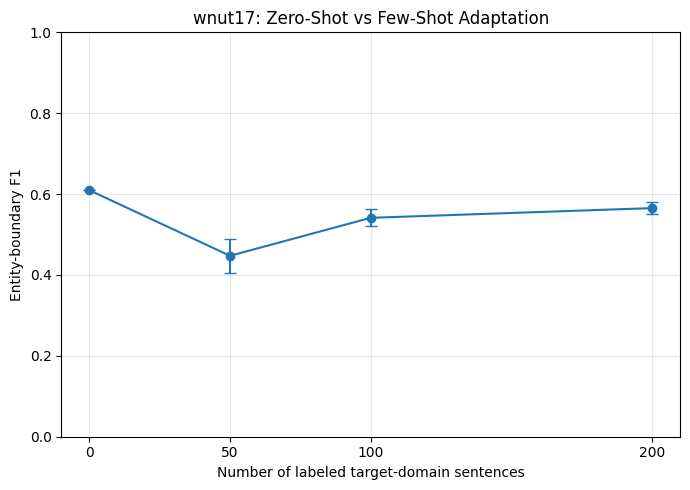

Saved: /content/drive/MyDrive/AAI590/data/processed/results/fewshot_v2/wnut17_boundary_learning_curve.png


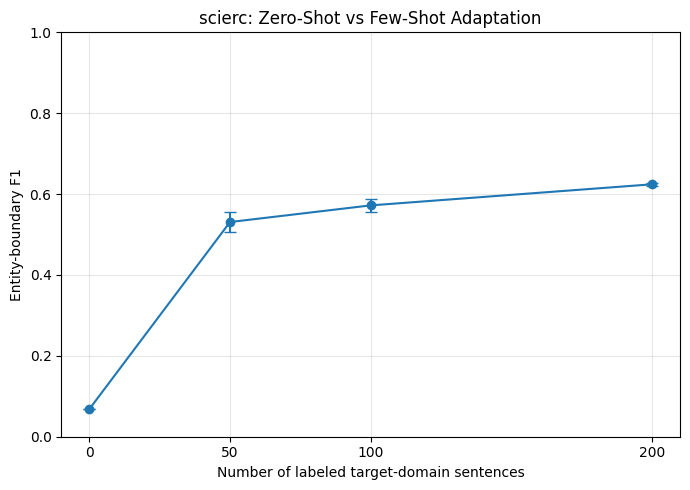

Saved: /content/drive/MyDrive/AAI590/data/processed/results/fewshot_v2/scierc_boundary_learning_curve.png


In [11]:
# Boundary-only F1: direct zero-shot versus few-shot comparison
for dataset_name in TARGET_DATASETS:
    plot_df = boundary_comparison_df[
        boundary_comparison_df["dataset"] == dataset_name
    ].sort_values("budget")

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        plot_df["budget"],
        plot_df["boundary_f1_mean"],
        yerr=plot_df["boundary_f1_std"].fillna(0),
        marker="o",
        capsize=4,
    )
    plt.xlabel("Number of labeled target-domain sentences")
    plt.ylabel("Entity-boundary F1")
    plt.title(f"{dataset_name}: Zero-Shot vs Few-Shot Adaptation")
    plt.xticks(sorted(plot_df["budget"].unique()))
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    output_path = (
        FEWSHOT_RESULTS_DIR /
        f"{dataset_name}_boundary_learning_curve.png"
    )
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


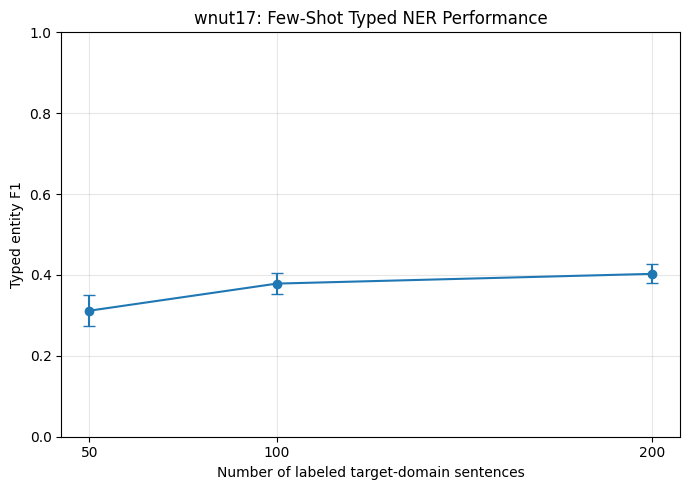

Saved: /content/drive/MyDrive/AAI590/data/processed/results/fewshot_v2/wnut17_typed_learning_curve.png


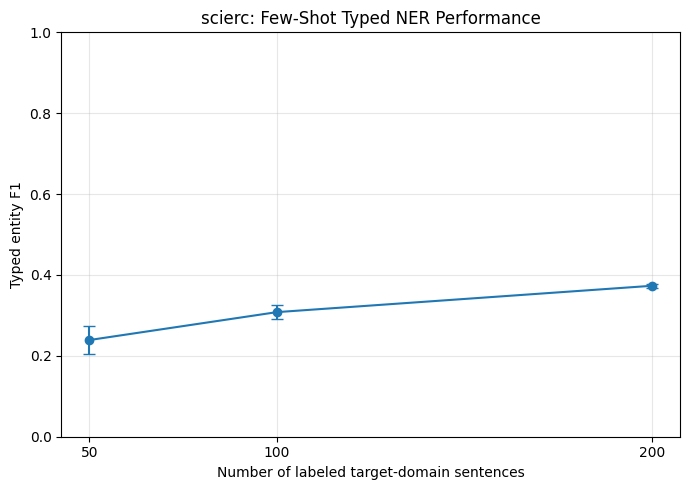

Saved: /content/drive/MyDrive/AAI590/data/processed/results/fewshot_v2/scierc_typed_learning_curve.png


In [12]:
# Typed target-domain F1: available after few-shot adaptation
typed_summary = (
    results_df
    .groupby(["dataset", "budget"])["test_typed_f1"]
    .agg(["mean", "std"])
    .reset_index()
)

for dataset_name in TARGET_DATASETS:
    plot_df = typed_summary[
        typed_summary["dataset"] == dataset_name
    ].sort_values("budget")

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        plot_df["budget"],
        plot_df["mean"],
        yerr=plot_df["std"].fillna(0),
        marker="o",
        capsize=4,
    )
    plt.xlabel("Number of labeled target-domain sentences")
    plt.ylabel("Typed entity F1")
    plt.title(f"{dataset_name}: Few-Shot Typed NER Performance")
    plt.xticks(sorted(plot_df["budget"].unique()))
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    output_path = (
        FEWSHOT_RESULTS_DIR /
        f"{dataset_name}_typed_learning_curve.png"
    )
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


## 10. Summary Table

In [13]:
presentation_rows = []

for dataset_name in TARGET_DATASETS:
    zero_row = boundary_comparison_df[
        (boundary_comparison_df["dataset"] == dataset_name) &
        (boundary_comparison_df["budget"] == 0)
    ]

    if not zero_row.empty:
        presentation_rows.append({
            "Dataset": dataset_name,
            "Training setup": "Zero-shot",
            "Budget": 0,
            "Typed F1": "N/A",
            "Boundary F1": f"{zero_row.iloc[0]['boundary_f1_mean']:.3f}",
        })

    for budget in BUDGETS:
        subset = results_df[
            (results_df["dataset"] == dataset_name) &
            (results_df["budget"] == budget)
        ]

        presentation_rows.append({
            "Dataset": dataset_name,
            "Training setup": "Few-shot",
            "Budget": budget,
            "Typed F1": (
                f"{subset['test_typed_f1'].mean():.3f} "
                f"± {subset['test_typed_f1'].std():.3f}"
            ),
            "Boundary F1": (
                f"{subset['test_boundary_f1'].mean():.3f} "
                f"± {subset['test_boundary_f1'].std():.3f}"
            ),
        })

presentation_df = pd.DataFrame(presentation_rows)
presentation_path = FEWSHOT_RESULTS_DIR / "presentation_results_table.csv"
presentation_df.to_csv(presentation_path, index=False)

display(presentation_df)
print("Saved:", presentation_path)


,Dataset,Training setup,Budget,Typed F1,Boundary F1
0,wnut17,Zero-shot,0,N/A,0.610
1,wnut17,Few-shot,50,0.312 ± 0.039,0.447 ± 0.043
2,wnut17,Few-shot,100,0.379 ± 0.027,0.541 ± 0.021
3,wnut17,Few-shot,200,0.403 ± 0.024,0.565 ± 0.014
4,scierc,Zero-shot,0,N/A,0.068
5,scierc,Few-shot,50,0.239 ± 0.035,0.531 ± 0.024
6,scierc,Few-shot,100,0.308 ± 0.017,0.572 ± 0.016
7,scierc,Few-shot,200,0.373 ± 0.005,0.624 ± 0.004


Saved: /content/drive/MyDrive/AAI590/data/processed/results/fewshot_v2/presentation_results_table.csv


## 11. Output Manifest

- `fewshot_results.csv` / `.json` — per-run results
- `fewshot_summary_by_budget.csv` — mean and standard deviation across seeds
- `zero_vs_fewshot_boundary_comparison.csv` — comparison with Notebook 04
- `presentation_results_table.csv` — summary table
- Boundary and typed-F1 learning-curve figures for WNUT-17 and SciERC


In [14]:
print("Notebook 05 outputs:")
for path in sorted(FEWSHOT_RESULTS_DIR.glob("*")):
    print(" -", path.name)


Notebook 05 outputs:
 - fewshot_results.csv
 - fewshot_results.json
 - fewshot_results_v2.csv
 - fewshot_results_v2.json
 - fewshot_summary_by_budget.csv
 - fewshot_summary_by_budget_and_lr.csv
 - presentation_results_table.csv
 - scierc_boundary_learning_curve.png
 - scierc_typed_learning_curve.png
 - wnut17_boundary_learning_curve.png
 - wnut17_typed_learning_curve.png
 - zero_vs_fewshot_boundary_comparison.csv
